# Real data: $J=0$ vs constant $J$ vs state-dependent $J(x)$

Constrained Bayesian regression with a non-differentiable penalty, on the **diabetes** dataset
(Efron et al., $n=442$; bundled with scikit-learn, no download). Three features are used,
`s1` (total serum cholesterol), `s2` (LDL) and `s5` (log serum triglycerides), chosen because `s1` and `s2`
carry a genuine **0.897** correlation — real multicollinearity, giving $\operatorname{cond}(A^\top A/n)=28.5$
and a posterior whose principal standard deviations differ by $5.3\times$. That anisotropy is what a
non-reversible perturbation is supposed to exploit.

Everything is standardized, and the potential splits as $U=f+g$ with

$$f(x)=\tfrac{\beta}{2}(x-\hat\mu)^\top\!\bigl(\tfrac1nA^\top\!A\bigr)(x-\hat\mu),
\qquad g\in\{\text{Lasso},\ \text{MCP},\ \text{SCAD}\},$$

$\hat\mu$ the OLS estimate, $\beta=200$. $U_0=f+g_0$ with $g_0$ the closed-form Gaussian smoothing.
The constraint is the ball $K=\{\lVert x\rVert\le0.85\}$, and it is **active**: $\lVert\hat\mu\rVert=0.994>R$,
so 63% of the unconstrained penalised posterior lies outside $K$.

The reference is exact, not another sampler: $f$ is quadratic and every penalty satisfies $g\ge0$, so
proposing $x\sim\mathcal N(\hat\mu,(\beta A^\top\!A/n)^{-1})$, accepting with probability $e^{-g(x)}$ and
keeping the draws inside $K$ is exact rejection sampling from the constrained posterior.

**$\alpha$ is held fixed throughout — no annealing.**

## $f$ is centered, and that is not cosmetic

$U$ is only defined up to an additive constant, but the skew drift $\alpha e^{U}J\nabla\psi$ is **not**
invariant to it: shifting $U\to U+c$ multiplies the drift by $e^{c}$ while leaving $\pi$ alone. The constant
is therefore absorbed into $\alpha$, and the sane convention is to center $f$ at the OLS residual so that
$e^{U}=O(1)$ at the mode. That is what the $f$ above does — it is the least-squares fit minus its minimum.

In [1]:
%matplotlib inline
import os, math
os.makedirs("figures", exist_ok=True)
import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

SQRT2 = math.sqrt(2.0)
INV_SQRT_2PI = 1.0 / math.sqrt(2.0 * math.pi)
def Phi(u): return 0.5 * (1.0 + torch.erf(u / SQRT2))
def phi(u): return INV_SQRT_2PI * torch.exp(-0.5 * u * u)
def PhiX(u):
    fin = torch.isfinite(u)
    step = torch.where(u > 0, torch.ones_like(u), torch.zeros_like(u))
    return torch.where(fin, Phi(torch.where(fin, u, torch.zeros_like(u))), step)
def phiX(u):
    fin = torch.isfinite(u)
    return torch.where(fin, phi(torch.where(fin, u, torch.zeros_like(u))), torch.zeros_like(u))
def uphiX(u):
    fin = torch.isfinite(u)
    uu = torch.where(fin, u, torch.zeros_like(u))
    return torch.where(fin, uu * phi(uu), torch.zeros_like(u))

## The closed-form smoothing lemma

For $p$ continuous and piecewise quadratic with $p(t)=c_{0,j}+c_{1,j}t+c_{2,j}t^2$ on $(t_j,t_{j+1})$, and
$u_j=(t_j-x)/\mu$,

$$P_j=\Phi(u_{j+1})-\Phi(u_j),\quad M_j=\phi(u_j)-\phi(u_{j+1}),\quad
Q_j=P_j+u_j\phi(u_j)-u_{j+1}\phi(u_{j+1}),$$

$$p_0(x)=\sum_j\Bigl\{(c_{0,j}+c_{1,j}x+c_{2,j}x^2)P_j+\mu(c_{1,j}+2c_{2,j}x)M_j+c_{2,j}\mu^2Q_j\Bigr\},
\qquad
p_0'(x)=\sum_j\Bigl\{(c_{1,j}+2c_{2,j}x)P_j+2c_{2,j}\mu M_j\Bigr\}.$$

One generic implementation covers all three regularizers; only the breakpoint/coefficient table changes.

In [2]:
class PiecewiseQuadratic:
    def __init__(self, breaks, coefs, name=""):
        self.t = list(breaks); self.c = [tuple(map(float, c)) for c in coefs]; self.name = name
        assert len(self.c) == len(self.t) + 1

    def raw(self, x):                       # the exact, non-differentiable penalty
        out = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            m = (x > ts[j]) & (x <= ts[j + 1])
            out = torch.where(m, c0 + c1 * x + c2 * x * x, out)
        return out

    def smooth(self, x, mu):                # (p0, p0') in closed form
        val = torch.zeros_like(x); grad = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            uj  = torch.full_like(x, -math.inf) if ts[j]     == -math.inf else (ts[j]     - x) / mu
            uj1 = torch.full_like(x,  math.inf) if ts[j + 1] ==  math.inf else (ts[j + 1] - x) / mu
            P = PhiX(uj1) - PhiX(uj)
            M = phiX(uj) - phiX(uj1)
            Q = P + uphiX(uj) - uphiX(uj1)
            val  = val  + (c0 + c1 * x + c2 * x * x) * P + mu * (c1 + 2 * c2 * x) * M + c2 * mu ** 2 * Q
            grad = grad + (c1 + 2 * c2 * x) * P + 2 * c2 * mu * M
        return val, grad

def lasso(lam):
    return PiecewiseQuadratic([0.0], [(0., -lam, 0.), (0., lam, 0.)], "Lasso")

def mcp(lam, a):
    return PiecewiseQuadratic([-a*lam, 0.0, a*lam],
        [(a*lam**2/2, 0., 0.), (0., -lam, -1/(2*a)), (0., lam, -1/(2*a)), (a*lam**2/2, 0., 0.)], "MCP")

def scad(lam, a):
    c = 1.0 / (2 * (a - 1))
    return PiecewiseQuadratic([-a*lam, -lam, 0.0, lam, a*lam],
        [(lam**2*(a+1)/2, 0., 0.), (-lam**2*c, -2*a*lam*c, -c), (0., -lam, 0.),
         (0., lam, 0.), (-lam**2*c, 2*a*lam*c, -c), (lam**2*(a+1)/2, 0., 0.)], "SCAD")

In [3]:
# --- the closed forms are checked against Monte Carlo and against finite differences
LAM, AA, MU = 1.0, 3.0, 0.3
xg = torch.linspace(-4, 4, 41)
torch.manual_seed(0); Z = torch.randn(2_000_000)
print("{:<7}{:>26}{:>28}{:>22}".format("", "max |closed - MC|", "max |p0' - d/dx p0|", "MC std err"))
print("-" * 84)
for P in [lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]:
    v, g = P.smooth(xg, MU)
    vmc = torch.stack([P.raw(xi + MU * Z).mean() for xi in xg])
    se  = float(torch.stack([P.raw(xi + MU * Z).std() for xi in xg]).max() / math.sqrt(len(Z)))
    h = 1e-5
    vp, _ = P.smooth(xg + h, MU); vm, _ = P.smooth(xg - h, MU)
    print("{:<7}{:>26.2e}{:>28.2e}{:>22.2e}".format(
        P.name, float((v - vmc).abs().max()), float((g - (vp - vm) / (2 * h)).abs().max()), se))
print("\n(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)")

                max |closed - MC|         max |p0' - d/dx p0|            MC std err
------------------------------------------------------------------------------------


Lasso                    1.93e-04                    7.92e-11              2.12e-04


MCP                      1.75e-04                    8.15e-11              1.62e-04


SCAD                     1.93e-04                    8.46e-11              2.06e-04

(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)


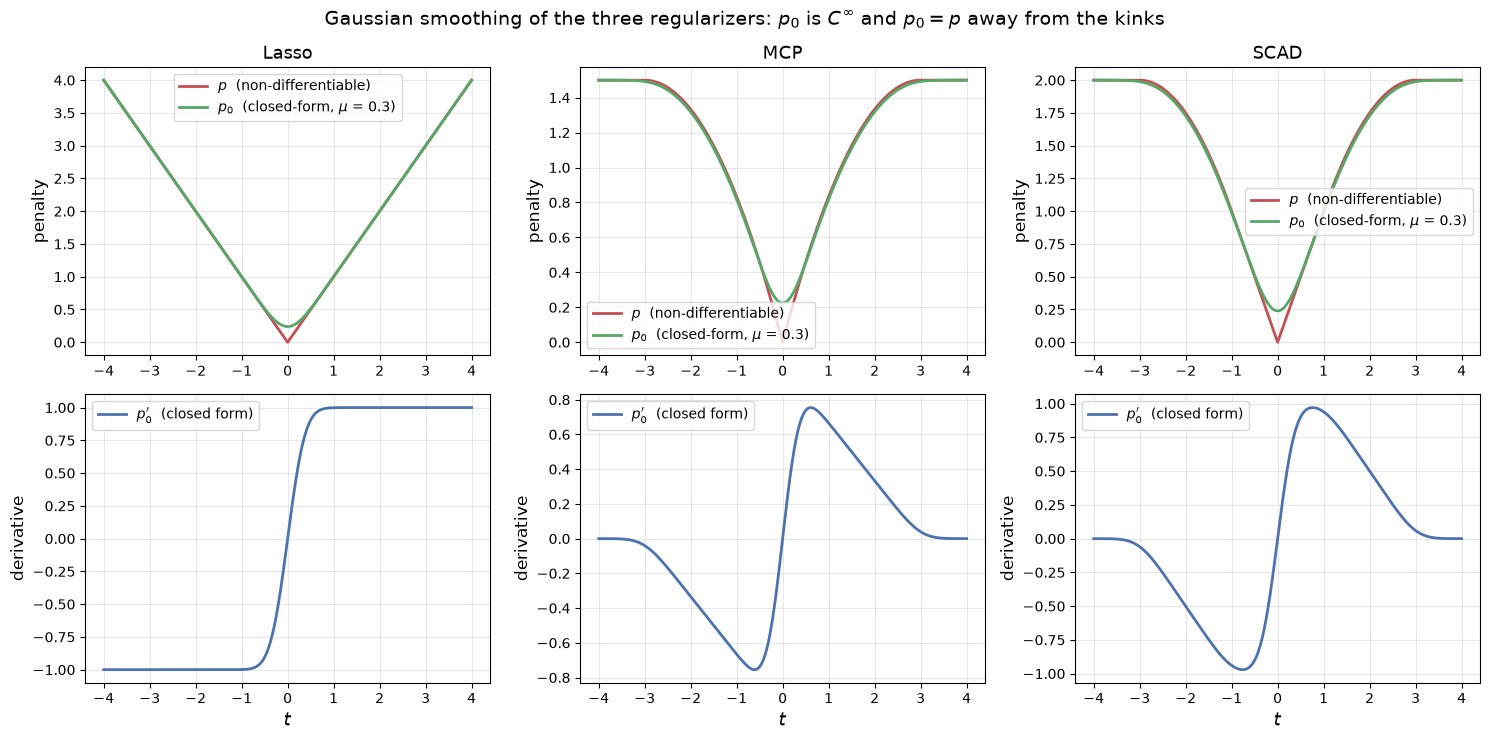

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
tt = torch.linspace(-4, 4, 601)
for j, P in enumerate([lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]):
    v, g = P.smooth(tt, MU)
    axes[0, j].plot(tt, P.raw(tt), linewidth=2, color="#C44E52", label="$p$  (non-differentiable)")
    axes[0, j].plot(tt, v, linewidth=2, color="#55A868", label=r"$p_0$  (closed-form, $\mu$ = 0.3)")
    axes[0, j].set_title(P.name, fontsize=13); axes[0, j].grid(alpha=0.3); axes[0, j].legend(fontsize=10)
    axes[0, j].set_ylabel("penalty", fontsize=12)
    axes[1, j].plot(tt, g, linewidth=2, color="#4C72B0", label="$p_0'$  (closed form)")
    axes[1, j].set_xlabel("$t$", fontsize=13); axes[1, j].set_ylabel("derivative", fontsize=12)
    axes[1, j].grid(alpha=0.3); axes[1, j].legend(fontsize=10)
fig.suptitle(r"Gaussian smoothing of the three regularizers: $p_0$ is $C^\infty$ and $p_0=p$ away from the kinks",
             fontsize=14)
plt.tight_layout()
plt.savefig("figures/pq_penalties.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# -----------------------------
# Real data: diabetes, 3 collinear features
# -----------------------------
from sklearn.datasets import load_diabetes
d = 3
FEATS = ("s1", "s2", "s5")
LAM, AA, MU_S = 1.0, 3.0, 0.05
BETA, R = 200.0, 0.85
N, ETA, MAXIT = 4000, 1e-4, 4000
SEEDS = [11, 22, 33]

_db = load_diabetes()
_X = (_db.data - _db.data.mean(0)) / _db.data.std(0)
_y = (_db.target - _db.target.mean()) / _db.target.std()
IDX = [_db.feature_names.index(t) for t in FEATS]
Amat = _X[:, IDX]; nobs = len(Amat)
Gm = Amat.T @ Amat / nobs
MU_OLS = np.linalg.solve(Amat.T @ Amat, Amat.T @ _y)
EVAL, EVEC = np.linalg.eigh(Gm)
G_T, MU_T = torch.tensor(Gm), torch.tensor(MU_OLS)
POST_SD = np.sqrt(np.linalg.eigvalsh(np.linalg.inv(BETA * Gm)))[::-1]

print("diabetes: n = {}, features {}".format(nobs, FEATS))
print("corr(s1,s2) = {:.3f}   cond(A'A/n) = {:.1f}".format(
    np.corrcoef(Amat[:, 0], Amat[:, 1])[0, 1], EVAL[-1] / EVAL[0]))
print("OLS mu = {}   ||mu|| = {:.3f}   ball R = {}  ->  constraint is ACTIVE".format(
    np.round(MU_OLS, 3), np.linalg.norm(MU_OLS), R))
print("posterior sd along principal directions = {}   (ratio {:.1f})".format(
    np.round(POST_SD, 4), POST_SD[0] / POST_SD[-1]))

class Target:
    # U = f + g,  f centered at the OLS residual;  U0 = f + g0 (closed form);  a = e^{U-U0}
    def __init__(self, pen, mu_s=MU_S, beta=BETA):
        self.pen, self.mu_s, self.beta = pen, mu_s, beta
    def f(self, x):
        z = x - MU_T
        return 0.5 * self.beta * ((z @ G_T) * z).sum(1)
    def gf(self, x): return self.beta * ((x - MU_T) @ G_T)
    def g(self, x):  return self.pen.raw(x).sum(1)
    def U(self, x):  return self.f(x) + self.g(x)
    def U0_and_grad(self, x):
        v, gr = self.pen.smooth(x, self.mu_s)
        return self.f(x) + v.sum(1), self.gf(x) + gr

def sample_target(T, n, rng, batch=400_000):
    L = np.linalg.cholesky(np.linalg.inv(T.beta * Gm))
    out = []
    while len(out) < n:
        z = MU_OLS + rng.normal(size=(batch, d)) @ L.T
        z = z[rng.random(len(z)) < np.exp(-T.g(torch.tensor(z)).numpy())]
        z = z[np.linalg.norm(z, axis=1) <= R]
        out.extend(z.tolist())
    return np.array(out[:n])

def proj(x):
    nn = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nn, max=1.0)

def on_boundary(X): return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))

diabetes: n = 442, features ('s1', 's2', 's5')
corr(s1,s2) = 0.897   cond(A'A/n) = 28.5
OLS mu = [-0.545  0.437  0.708]   ||mu|| = 0.994   ball R = 0.85  ->  constraint is ACTIVE
posterior sd along principal directions = [0.2552 0.0826 0.0478]   (ratio 5.3)


## The three $J$ variants, and why $h=1$ cannot be used here

$\psi=(R^2-\lVert x\rVert^2)\,h$. On $\partial K$ the first factor vanishes, so $\nabla\psi=-2xh\parallel\nu$
for **any** smooth $h$ — tangency is automatic. Two choices of $h$:

* $h=1$: $\nabla\psi=-2x$, so the drift scales with $e^{U}$;
* $h=e^{-U_0}$: $\nabla\psi=e^{-U_0}\bigl[-2x-(R^2-\lVert x\rVert^2)\nabla U_0\bigr]$, so the drift scales
  with $a(x)=e^{U-U_0}\in(0,1]$.

On the synthetic target of the previous notebooks these were merely different; here they are not. A real
posterior with $\beta=200$ is sharply peaked, and $e^{U}$ measured on $\partial K$ reaches $\sim10^{124}$.
The $h=1$ drift is then astronomically large anywhere off the posterior's support, and no $\alpha$ makes it
both stable and useful — quantified below.

The $J$ variants, all of the family $J(x)w=k(x)\times w$ with $k=\nabla\chi$ curl-free (so
$\nabla\!\cdot(J\nabla\psi)=0$ exactly):

| variant | $k$ |
|---|---|
| $J=0$ | — |
| constant $J$ | the smallest-posterior-variance eigenvector ($\chi$ linear) |
| state-dependent $J(x)$ | $\nabla U_0(x)$ |

In [6]:
def J_from_axis(w):
    w = np.asarray(w, float); w = w / np.linalg.norm(w)
    return torch.tensor([[0., -w[2], w[1]], [w[2], 0., -w[0]], [-w[1], w[0], 0.]])
AXIS = EVEC[:, -1]                      # smallest posterior variance
AXIS_T = torch.tensor(AXIS)
print("aligned rotation axis (smallest posterior sd) =", np.round(AXIS, 3))

@torch.no_grad()
def skew_drift(T, x, kind, alpha, U0, gU0, Uv, h="temper"):
    if alpha == 0.0 or kind == "none": return torch.zeros_like(x)
    s = R ** 2 - (x * x).sum(1)
    if h == "one":
        vec, scale = -2.0 * x, torch.exp(Uv)
    else:
        vec, scale = -(2.0 * x + s.unsqueeze(1) * gU0), torch.exp(Uv - U0)
    k = gU0 if kind == "sd" else AXIS_T.expand_as(x)
    return alpha * scale.unsqueeze(1) * torch.cross(k, vec, dim=1)

@torch.no_grad()
def run_chain(T, alpha, ref, seed=11, kind="const", h="temper", n_steps=MAXIT, eta=ETA, N=N,
              every=10, track=True):
    torch.manual_seed(seed)
    x = proj(torch.zeros(N, d))
    it, W, mx, blew = [], [], 0.0, False
    for k in range(n_steps):
        U0, gU0 = T.U0_and_grad(x)
        Uv = T.U(x)
        a = torch.exp(Uv - U0)
        sk = skew_drift(T, x, kind, alpha, U0, gU0, Uv, h)
        if alpha != 0.0: mx = max(mx, float((eta * sk).norm(dim=1).max()))
        x = proj(x - eta * a.unsqueeze(1) * gU0 + eta * sk
                 + torch.sqrt(2 * eta * a).unsqueeze(1) * torch.randn_like(x))
        if not torch.isfinite(x).all(): blew = True; break
        if track and (k + 1) % every == 0:
            xn = x.numpy(); it.append(k + 1)
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(it), (np.array(W) if track else None), mx, blew

def ensemble(T, alpha, ref, seeds=SEEDS, **kw):
    C, X, it, W1 = [], None, None, None
    for j, sd in enumerate(seeds):
        X, it, W, mx, blew = run_chain(T, alpha, ref, seed=sd, **kw)
        if j == 0: W1 = W
        C.append(W.mean(axis=1))
    return it, np.array(C), X, W1

def tau(it, c, eps):
    bad = np.where(c > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])

def tau_mean(it, C, eps):
    v = [tau(it, c, eps) for c in C]
    return float(np.nanmean(v)) if np.any(np.isfinite(v)) else np.nan

aligned rotation axis (smallest posterior sd) = [-0.653 -0.611 -0.446]


In [7]:
PENS = {"Lasso": lasso(LAM), "MCP": mcp(LAM, AA), "SCAD": scad(LAM, AA)}
TARGETS, refs, floors = {}, {}, {}
rng = np.random.default_rng(0)
for nm, pen in PENS.items():
    T = Target(pen); TARGETS[nm] = T
    refs[nm] = sample_target(T, N, rng)
    floors[nm] = float(np.mean([[wasserstein_distance(refs[nm][:, i], sample_target(T, N, rng)[:, i])
                                 for i in range(d)] for _ in range(4)]))
    print("{:<6} floor {:.5f}   target boundary mass {:.4f}".format(nm, floors[nm], on_boundary(refs[nm])))

T = TARGETS["Lasso"]
xt = torch.tensor(refs["Lasso"]); U0t, gU0t = T.U0_and_grad(xt); Ut = T.U(xt)
xb = torch.randn(20000, d); xb = R * xb / xb.norm(dim=1, keepdim=True)
print("\ne^U on the posterior:     median {:.1f}      max {:.1e}".format(
    float(Ut.exp().median()), float(Ut.exp().max())))
print("e^U on the sphere dK:     median {:.1e}   max {:.1e}   <- what h = 1 multiplies by".format(
    float(T.U(xb).exp().median()), float(T.U(xb).exp().max())))
print("a(x) = e^(U-U0):          min {:.3f}       max {:.3f}     <- what h = e^-U0 multiplies by".format(
    float((Ut - U0t).exp().min()), float((Ut - U0t).exp().max())))

nub = xb / R
U0b, gU0b = T.U0_and_grad(xb); Ub = T.U(xb)
print("\ntangency on dK,  max |(J grad psi).nu| / ||J grad psi||:")
for h in ["one", "temper"]:
    for kind in ["const", "sd"]:
        v = skew_drift(T, xb, kind, 1.0, U0b, gU0b, Ub, h)
        print("   h = {:<7} k = {:<6} {:.2e}".format(h, kind, float(
            ((v * nub).sum(1) / v.norm(dim=1).clamp(min=1e-300)).abs().max())))
xr = torch.randn(200, d, requires_grad=True)
v0, g0 = T.pen.smooth(xr, T.mu_s); U0r = T.f(xr) + v0.sum(1); gU0r = T.gf(xr) + g0
gpsi = torch.exp(-U0r).unsqueeze(1) * (-(2.0 * xr + (R ** 2 - (xr * xr).sum(1)).unsqueeze(1) * gU0r))
print("invariance,      max |div(J grad psi)|:")
for kind, kk in [("const", AXIS_T.expand_as(xr) + 0.0 * xr), ("sd", gU0r)]:
    c = torch.cross(kk, gpsi, dim=1)
    div = sum(torch.autograd.grad(c[:, i].sum(), xr, retain_graph=True)[0][:, i] for i in range(d))
    print("   k = {:<6} {:.2e}".format(kind, float(div.abs().max())))

Lasso  floor 0.00246   target boundary mass 0.0045


MCP    floor 0.00286   target boundary mass 0.0040


SCAD   floor 0.00318   target boundary mass 0.0045

e^U on the posterior:     median 18.7      max 1.5e+05
e^U on the sphere dK:     median 1.9e+43   max 7.9e+124   <- what h = 1 multiplies by
a(x) = e^(U-U0):          min 0.936       max 1.000     <- what h = e^-U0 multiplies by

tangency on dK,  max |(J grad psi).nu| / ||J grad psi||:
   h = one     k = const  1.74e-15
   h = one     k = sd     2.78e-15
   h = temper  k = const  3.17e-14
   h = temper  k = sd     2.62e-15
invariance,      max |div(J grad psi)|:
   k = const  2.22e-16
   k = sd     5.33e-15


## Experiment 1 — choose $\alpha$ (fixed, not annealed)

$\alpha$ is swept for both admissible fields with $h=e^{-U_0}$. For $h=1$ no sweep is possible: the drift
is proportional to $e^{U}$, so keeping it finite where $e^{U}\sim10^{124}$ forces $\alpha\sim10^{-40}$, at
which point the skew term contributes nothing in the bulk. Both facts are shown.

In [8]:
EPS = (0.05, 0.02, 0.01)
it0, C0, X0, _ = ensemble(TARGETS["Lasso"], 0.0, refs["Lasso"], kind="none")
base = {e: tau_mean(it0, C0, e) for e in EPS}
print("Lasso, floor {:.5f};  J = 0: tau = {:.0f} / {:.0f} / {:.0f}, W1@500 {:.4f}, stationary {:.5f}\n".format(
    floors["Lasso"], base[0.05], base[0.02], base[0.01], C0.mean(axis=0)[49], C0.mean(axis=0)[-20:].mean()))
print("{:<9}{:<8}{:<9}{:>15}{:>15}{:>15}{:>14}{:>16}".format(
    "h", "k", "alpha", "tau(0.05)", "tau(0.02)", "tau(0.01)", "W1 @ 500", "W1 stationary"))
print("-" * 101)
for h, kind, alphas in [("one", "const", [1e-40]), ("one", "sd", [1e-40]),
                        ("temper", "const", [0.5, 1.0, 2.0, 4.0]),
                        ("temper", "sd", [0.5, 1.0, 2.0, 4.0])]:
    for al in alphas:
        it, C, X, _ = ensemble(TARGETS["Lasso"], al, refs["Lasso"], kind=kind, h=h)
        m = C.mean(axis=0)
        cells = []
        for e in EPS:
            v = tau_mean(it, C, e)
            cells.append("{:.0f} ({:.1f}x)".format(v, base[e] / v) if np.isfinite(v) else "n/a")
        print("{:<9}{:<8}{:<9}{:>15}{:>15}{:>15}{:>14}{:>16}".format(
            h, kind, "{:g}".format(al), cells[0], cells[1], cells[2],
            "{:.4f}".format(m[49]), "{:.5f}".format(m[-20:].mean())))
print("\n(the h = 1 rows reproduce J = 0 exactly -- at the only alpha that does not overflow,"
      "\n the skew term is numerically absent)")

Lasso, floor 0.00246;  J = 0: tau = 487 / 743 / 933, W1@500 0.0464, stationary 0.00416

h        k       alpha          tau(0.05)      tau(0.02)      tau(0.01)      W1 @ 500   W1 stationary
-----------------------------------------------------------------------------------------------------


one      const   1e-40         487 (1.0x)     743 (1.0x)     933 (1.0x)        0.0464         0.00416


one      sd      1e-40         487 (1.0x)     743 (1.0x)     933 (1.0x)        0.0464         0.00416


temper   const   0.5           313 (1.6x)     550 (1.4x)     743 (1.3x)        0.0228         0.00403


temper   const   1             160 (3.0x)     260 (2.9x)     367 (2.5x)        0.0058         0.00390


...

temper   const   4             223 (2.2x)     377 (2.0x)     470 (2.0x)        0.0083         0.00324


temper   sd      0.5           363 (1.3x)     550 (1.4x)     697 (1.3x)        0.0242         0.00437


temper   sd      1             287 (1.7x)     407 (1.8x)     493 (1.9x)        0.0090         0.00424


temper   sd      2             240 (2.0x)     337 (2.2x)     413 (2.3x)        0.0039         0.00410


temper   sd      4             230 (2.1x)     320 (2.3x)     427 (2.2x)        0.0065         0.00667

(the h = 1 rows reproduce J = 0 exactly -- at the only alpha that does not overflow,
 the skew term is numerically absent)


## Experiment 2 — the three variants on each regularizer

Fixed $\alpha$: $1$ for the constant field, $2$ for the state-dependent one, both from Experiment 1.

In [9]:
SCHEMES = [("J = 0", "none", 0.0),
           ("constant J,  alpha = 1", "const", 1.0),
           ("state-dependent J,  alpha = 2", "sd", 2.0)]
final = {}
for nm in PENS:
    Tn = TARGETS[nm]
    print("\n### {}   floor {:.5f}   target boundary mass {:.4f}".format(nm, floors[nm], on_boundary(refs[nm])))
    print("{:<32}{:>15}{:>15}{:>15}{:>14}{:>16}{:>9}".format(
        "scheme", "tau(0.05)", "tau(0.02)", "tau(0.01)", "W1 @ 500", "W1 stationary", "on dK"))
    print("-" * 116)
    base, final[nm] = {}, {}
    for lab, kind, al in SCHEMES:
        it, C, X, W1 = ensemble(Tn, al, refs[nm], kind=kind)
        m = C.mean(axis=0)
        cells = []
        for e in EPS:
            v = tau_mean(it, C, e)
            if al == 0.0: base[e] = v
            cells.append("{:.0f} ({:.1f}x)".format(v, base[e] / v) if np.isfinite(v) else "n/a")
        final[nm][lab] = {"it": it, "C": C, "x": X, "W1": W1}
        print("{:<32}{:>15}{:>15}{:>15}{:>14}{:>16}{:>9.4f}".format(
            lab, cells[0], cells[1], cells[2], "{:.4f}".format(m[49]),
            "{:.5f}".format(m[-20:].mean()), on_boundary(X)))


### Lasso   floor 0.00246   target boundary mass 0.0045
scheme                                tau(0.05)      tau(0.02)      tau(0.01)      W1 @ 500   W1 stationary    on dK
--------------------------------------------------------------------------------------------------------------------


J = 0                                487 (1.0x)     743 (1.0x)     933 (1.0x)        0.0464         0.00416   0.0542


constant J,  alpha = 1               160 (3.0x)     260 (2.9x)     367 (2.5x)        0.0058         0.00390   0.0535


state-dependent J,  alpha = 2        240 (2.0x)     337 (2.2x)     413 (2.3x)        0.0039         0.00410   0.0540

### MCP   floor 0.00286   target boundary mass 0.0040
scheme                                tau(0.05)      tau(0.02)      tau(0.01)      W1 @ 500   W1 stationary    on dK
--------------------------------------------------------------------------------------------------------------------


J = 0                                487 (1.0x)     753 (1.0x)     953 (1.0x)        0.0470         0.00393   0.0553


constant J,  alpha = 1               170 (2.9x)     267 (2.8x)     390 (2.4x)        0.0061         0.00358   0.0550


state-dependent J,  alpha = 2        243 (2.0x)     337 (2.2x)     420 (2.3x)        0.0044         0.00406   0.0550

### SCAD   floor 0.00318   target boundary mass 0.0045
scheme                                tau(0.05)      tau(0.02)      tau(0.01)      W1 @ 500   W1 stationary    on dK
--------------------------------------------------------------------------------------------------------------------


J = 0                                493 (1.0x)     770 (1.0x)     997 (1.0x)        0.0479         0.00361   0.0542


constant J,  alpha = 1               170 (2.9x)     270 (2.9x)     417 (2.4x)        0.0072         0.00332   0.0535


state-dependent J,  alpha = 2        250 (2.0x)     347 (2.2x)     427 (2.3x)        0.0049         0.00377   0.0540


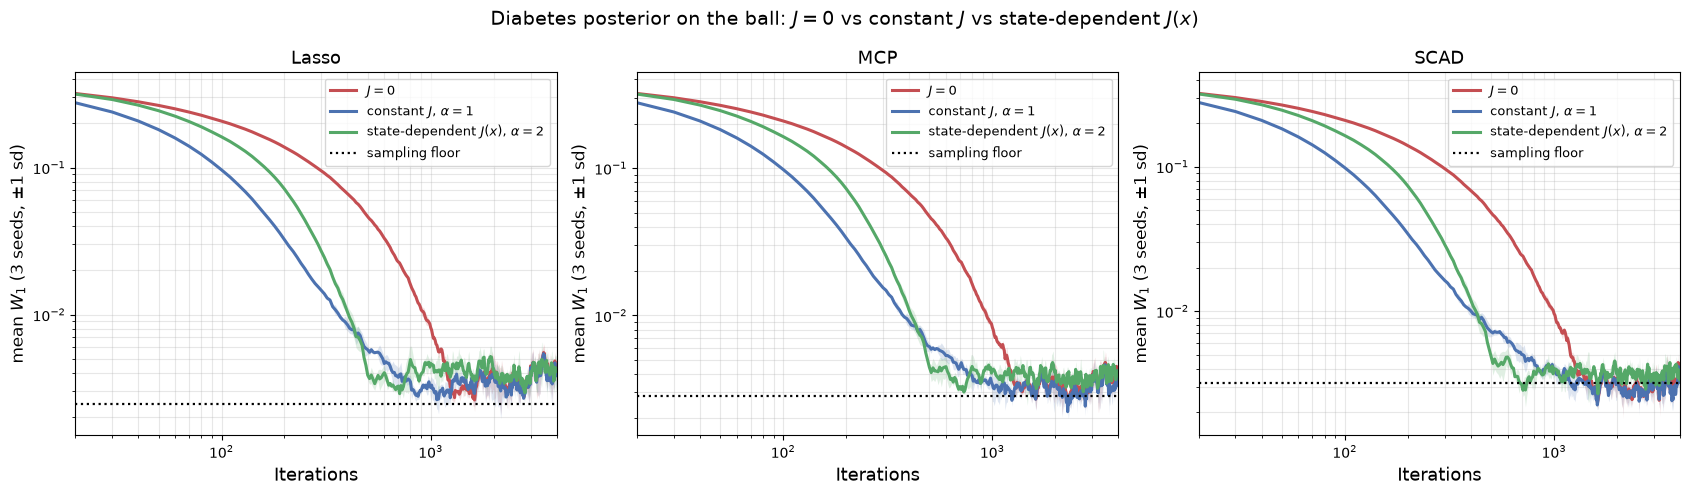

In [10]:
LAB = [s[0] for s in SCHEMES]
CB = {LAB[0]: "#C44E52", LAB[1]: "#4C72B0", LAB[2]: "#55A868"}
SH = {LAB[0]: "$J = 0$", LAB[1]: r"constant $J$, $\alpha=1$", LAB[2]: r"state-dependent $J(x)$, $\alpha=2$"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nm in zip(axes, PENS):
    for lab in LAB:
        r = final[nm][lab]
        m, sv = r["C"].mean(axis=0), r["C"].std(axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=CB[lab], label=SH[lab])
        ax.fill_between(r["it"], m - sv, m + sv, color=CB[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel("mean $W_1$ (3 seeds, $\\pm$1 sd)", fontsize=12)
    ax.set_title(nm, fontsize=13); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9.5)
fig.suptitle("Diabetes posterior on the ball: $J=0$ vs constant $J$ vs state-dependent $J(x)$", fontsize=14)
plt.tight_layout()
plt.savefig("figures/real_headtohead.pdf", dpi=300, bbox_inches="tight")
plt.show()

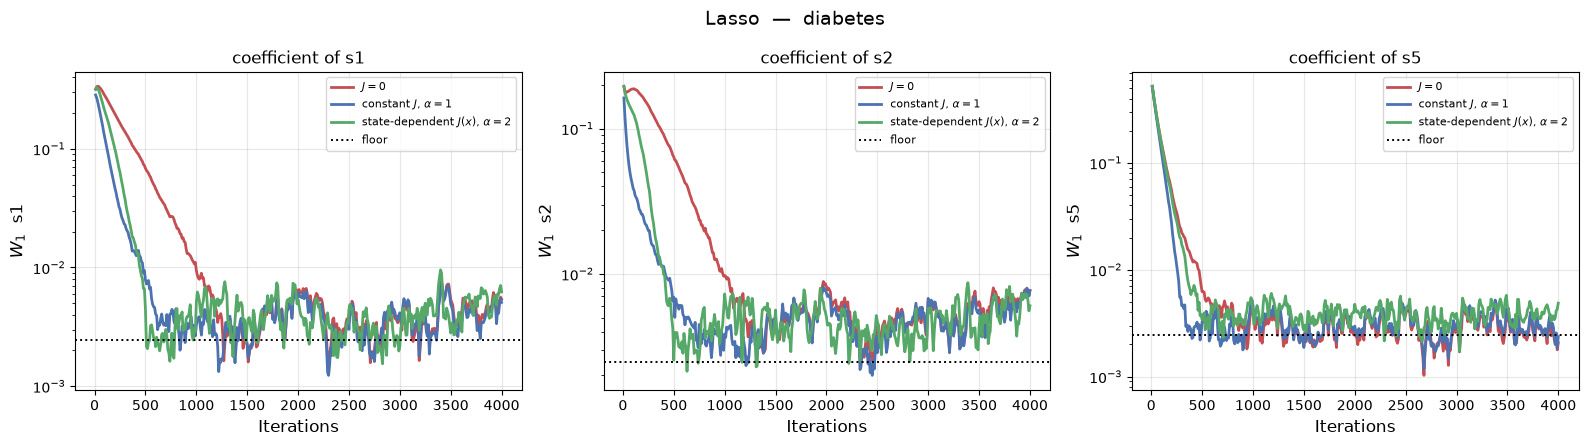

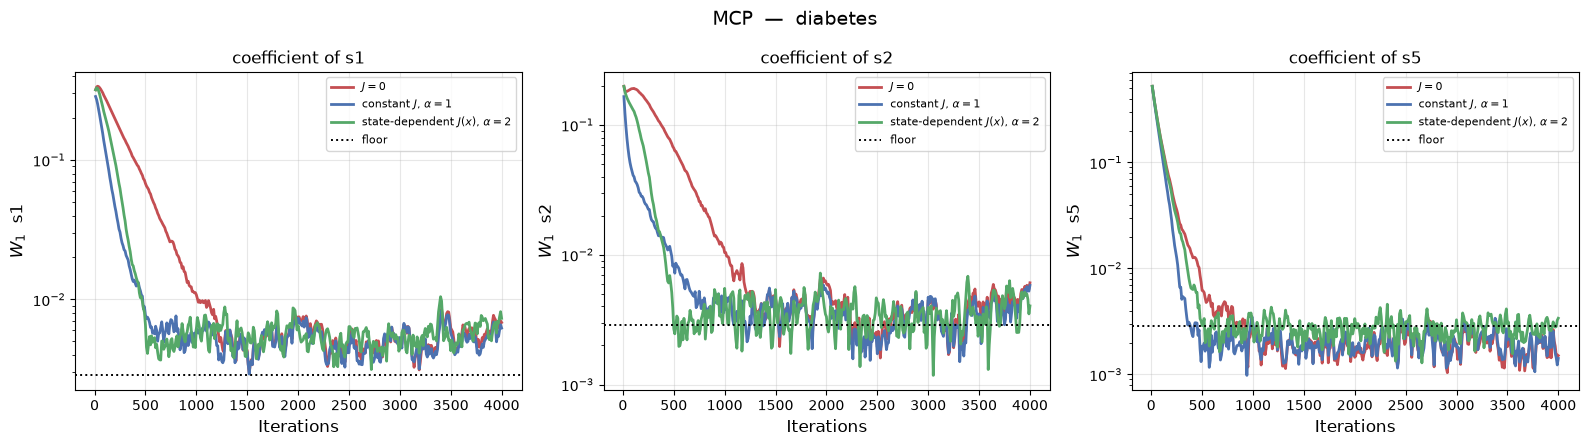

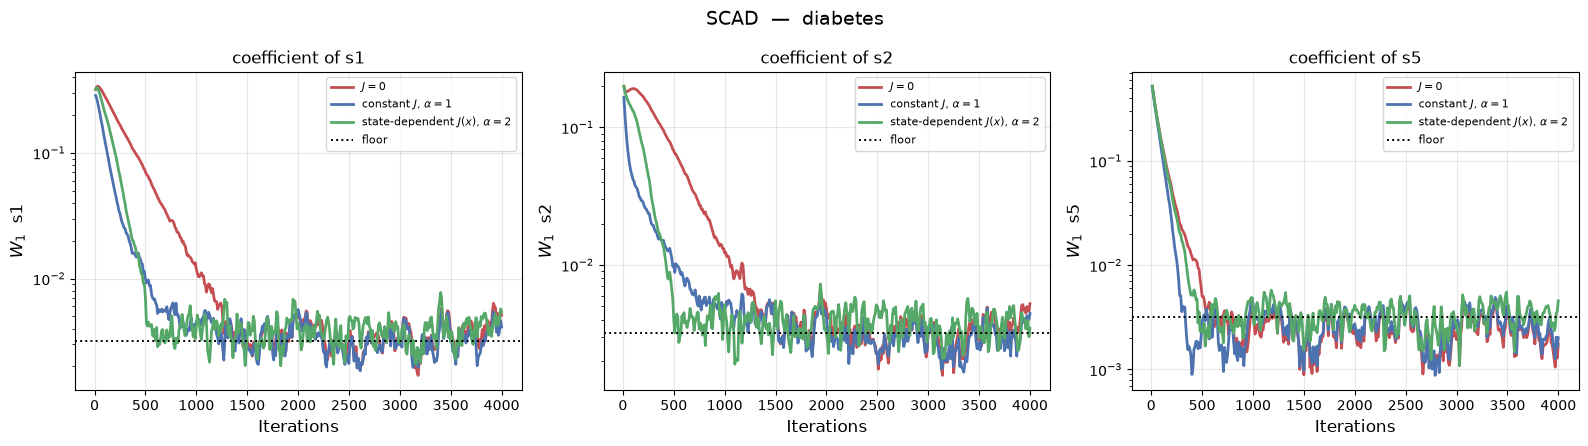

In [11]:
for nm in PENS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for i, ax in enumerate(axes):
        for lab in LAB:
            r = final[nm][lab]
            ax.plot(r["it"], r["W1"][:, i], linewidth=2, color=CB[lab], label=SH[lab])
        ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.4, label="floor")
        ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=12)
        ax.set_ylabel("$W_1$  {}".format(FEATS[i]), fontsize=12)
        ax.set_title("coefficient of {}".format(FEATS[i]), fontsize=12)
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(nm + "  —  diabetes", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/real_w1_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

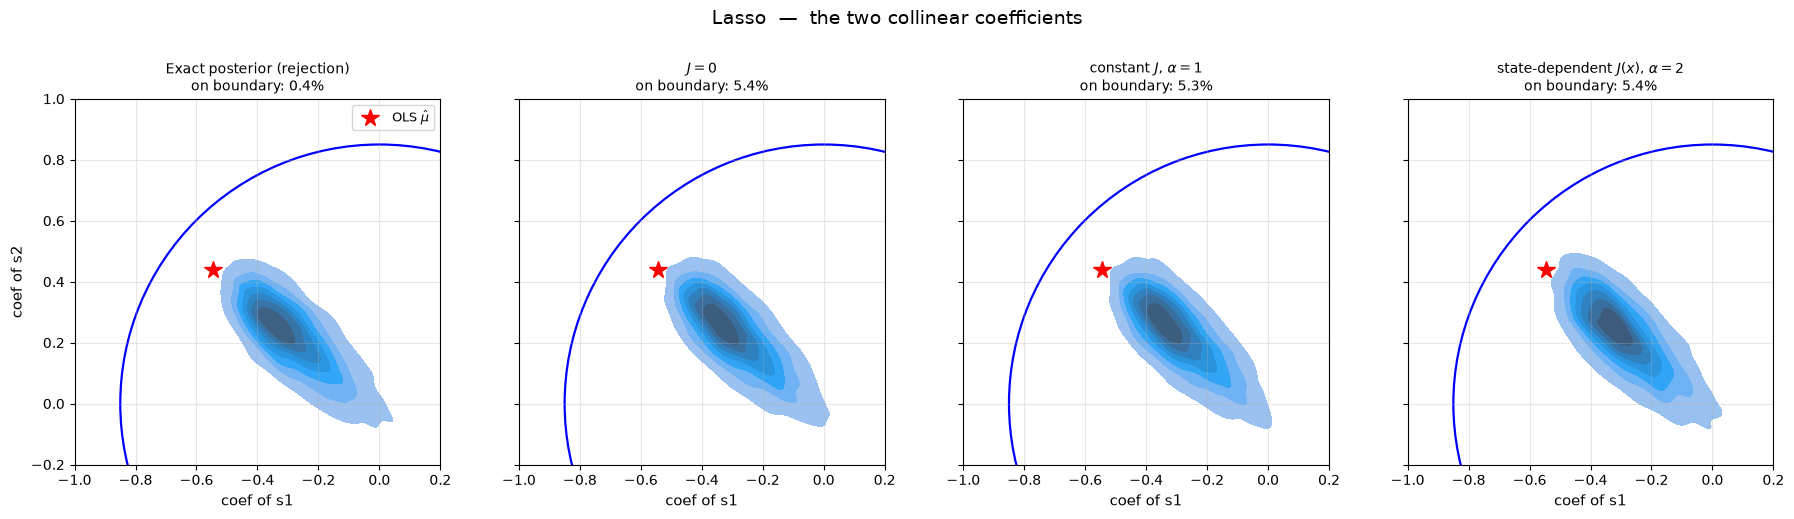

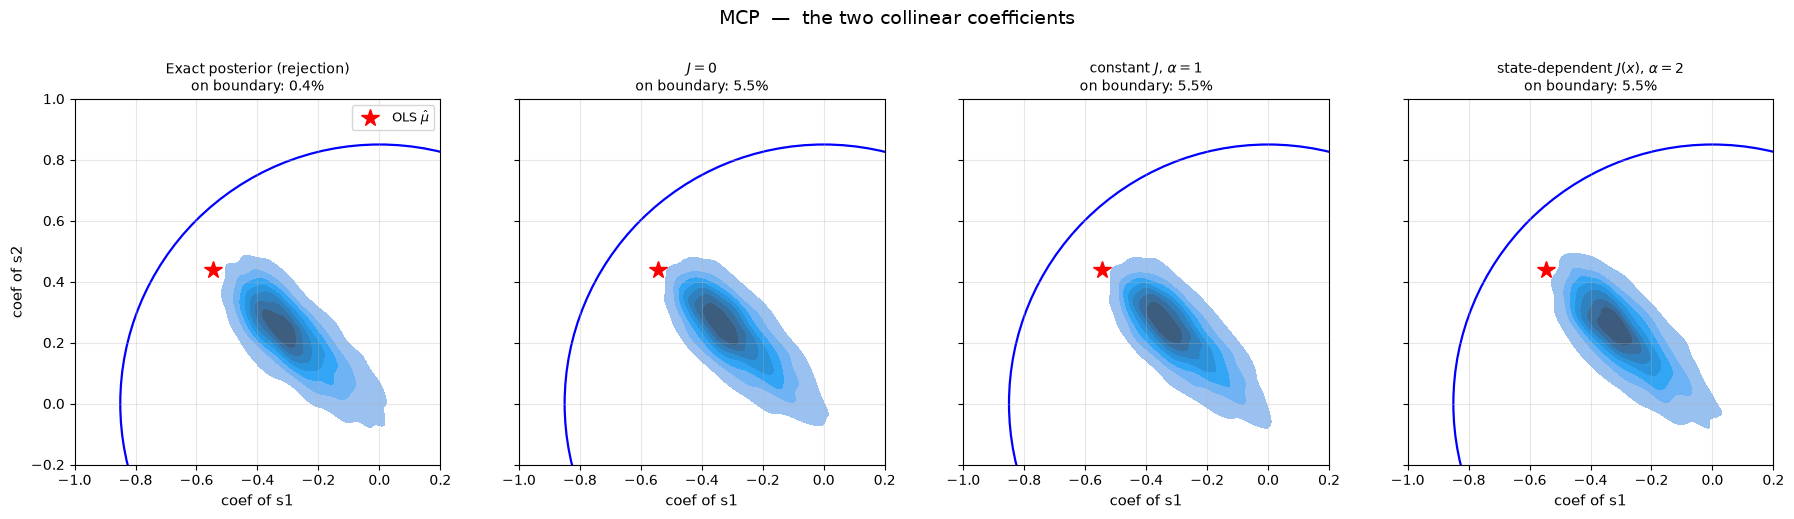

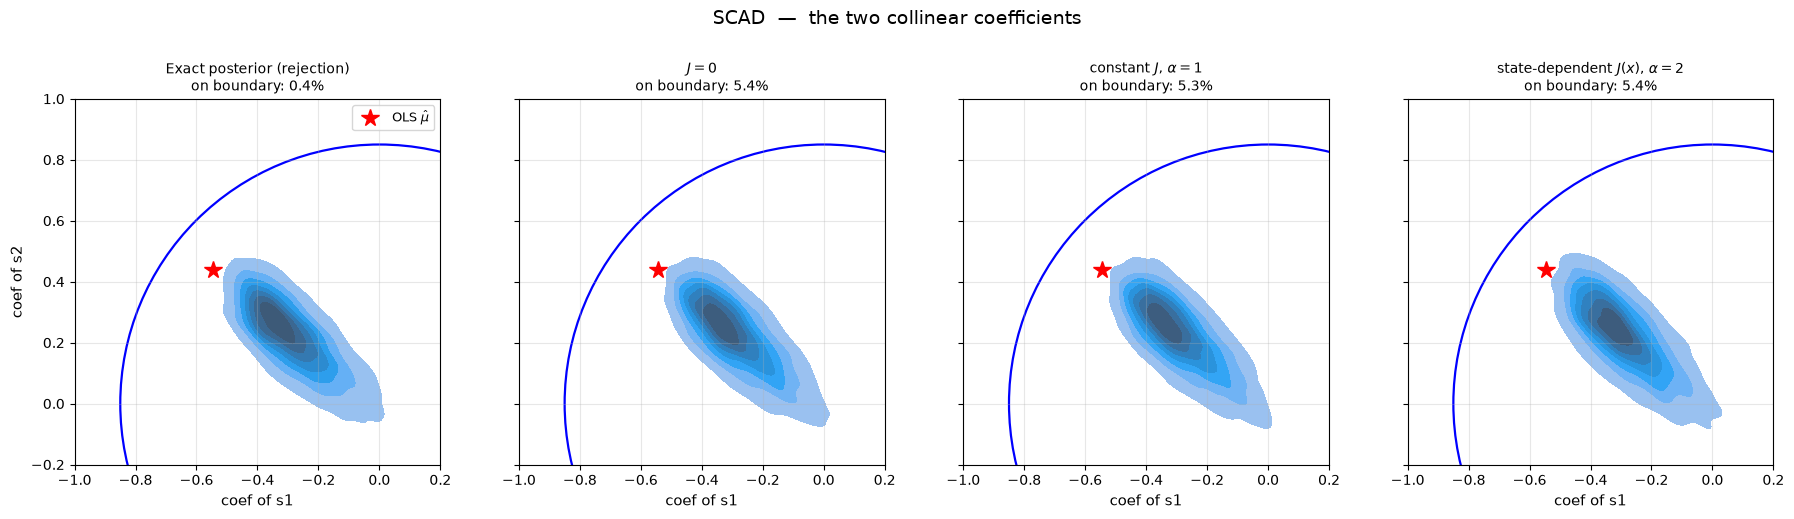

In [12]:
for nm in PENS:
    panels = [("Exact posterior (rejection)", refs[nm])] + [(SH[l], final[nm][l]["x"]) for l in LAB]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 4.7), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.plot([MU_OLS[0]], [MU_OLS[1]], "r*", markersize=13, label="OLS $\\hat\\mu$")
        ax.set_xlim(-1.0, 0.2); ax.set_ylim(-0.2, 1.0)
        ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel("coef of {}".format(FEATS[0]), fontsize=11); ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("coef of {}".format(FEATS[1]), fontsize=11); axes[0].legend(fontsize=9)
    fig.suptitle(nm + "  —  the two collinear coefficients", fontsize=14, y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/real_density_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — did either field move the posterior?

In [13]:
print("{:<34}{:>12}{:>12}{:>30}".format("scheme (terminal ensemble)", "max KS", "on dK", "per-coordinate W1"))
print("-" * 90)
for nm in PENS:
    print("{}   target boundary mass {:.4f}   floor {:.5f}".format(nm, on_boundary(refs[nm]), floors[nm]))
    for lab in LAB:
        X = final[nm][lab]["x"]
        ks = max(ks_2samp(refs[nm][:, i], X[:, i]).statistic for i in range(d))
        w = [wasserstein_distance(refs[nm][:, i], X[:, i]) for i in range(d)]
        print("{:<34}{:>12.4f}{:>12.4f}{:>30}".format("  " + lab, ks, on_boundary(X),
                                                      np.array2string(np.round(w, 5))))
print("\nposterior mean of each coefficient (exact vs sampled), Lasso:")
print("   {:<28}{}".format("exact", np.round(refs["Lasso"].mean(0), 4)))
for lab in LAB:
    print("   {:<28}{}".format(lab, np.round(final["Lasso"][lab]["x"].mean(0), 4)))
print("   {:<28}{}".format("OLS (unpenalised, outside K)", np.round(MU_OLS, 4)))

scheme (terminal ensemble)              max KS       on dK             per-coordinate W1
------------------------------------------------------------------------------------------
Lasso   target boundary mass 0.0045   floor 0.00246
  J = 0                                 0.0370      0.0542     [0.00513 0.00718 0.00204]
  constant J,  alpha = 1                0.0367      0.0535     [0.00443 0.00625 0.00224]
  state-dependent J,  alpha = 2         0.0400      0.0540     [0.00314 0.00399 0.00403]
MCP   target boundary mass 0.0040   floor 0.00286
  J = 0                                 0.0400      0.0553     [0.00602 0.00507 0.0014 ]
  constant J,  alpha = 1                0.0355      0.0550     [0.00553 0.00442 0.00142]
  state-dependent J,  alpha = 2         0.0300      0.0550     [0.00402 0.00293 0.00361]
SCAD   target boundary mass 0.0045   floor 0.00318
  J = 0                                 0.0357      0.0542     [0.00384 0.00435 0.00178]
  constant J,  alpha = 1                0.02

## Summary

**Both skew fields beat $J=0$ on real data, on all three regularizers, at fixed $\alpha$.**

| | $\tau(0.05)$ | $\tau(0.02)$ | $\tau(0.01)$ | $W_1$ @ 500 | $W_1$ stationary | on $\partial K$ |
|---|---|---|---|---|---|---|
| **Lasso** $J=0$ | 487 | 743 | 933 | 0.0464 | 0.00416 | 5.42% |
| **Lasso** constant $J$ | **160 (3.0×)** | **260 (2.9×)** | **367 (2.5×)** | 0.0058 | 0.00390 | 5.35% |
| **Lasso** state-dep. $J$ | 240 (2.0×) | 337 (2.2×) | 413 (2.3×) | **0.0039** | 0.00410 | 5.40% |
| **MCP** $J=0$ | 487 | 753 | 953 | 0.0470 | 0.00393 | 5.53% |
| **MCP** constant $J$ | **170 (2.9×)** | **267 (2.8×)** | **390 (2.4×)** | 0.0061 | 0.00358 | 5.50% |
| **MCP** state-dep. $J$ | 243 (2.0×) | 337 (2.2×) | 420 (2.3×) | **0.0044** | 0.00406 | 5.50% |
| **SCAD** $J=0$ | 493 | 770 | 997 | 0.0479 | 0.00361 | 5.42% |
| **SCAD** constant $J$ | **170 (2.9×)** | **270 (2.9×)** | **417 (2.4×)** | 0.0072 | 0.00332 | 5.35% |
| **SCAD** state-dep. $J$ | 250 (2.0×) | 347 (2.2×) | 427 (2.3×) | **0.0049** | 0.00377 | 5.40% |

The constant field wins on iteration count ($2.4$–$3.0\times$); the state-dependent field wins on error at
a fixed 500-iteration budget ($8$–$12\times$ lower than $J=0$, and better than the constant field). The
three penalties agree to within a few percent throughout, which is the expected outcome — the skew field
acts through $\nabla\psi$ and the geometry of $K$, and the penalty enters only via $a(x)=e^{g-g_0}$.

**Nothing moved the posterior.** Boundary mass is unchanged to within $0.2$ percentage points, max KS is
equal or better with $J$ on every penalty (SCAD $0.0357\to0.0290/0.0285$), and the posterior means agree to
three decimals:

| | coef `s1` | coef `s2` | coef `s5` |
|---|---|---|---|
| exact (rejection) | $-0.2868$ | $0.2184$ | $0.6169$ |
| $J=0$ | $-0.2919$ | $0.2255$ | $0.6189$ |
| constant $J$ | $-0.2912$ | $0.2246$ | $0.6191$ |
| state-dependent $J$ | $-0.2898$ | $0.2222$ | $0.6201$ |
| OLS $\hat\mu$ (unpenalised) | $-0.545$ | $0.4375$ | $0.7076$ |

The last row is the point of the exercise: the constrained penalised posterior pulls the two collinear
coefficients roughly halfway back from OLS toward zero, which is what the constraint plus the penalty are
for, and every sampler agrees on where it lands.

**The result that did not survive contact with real data: $h=1$.** In the synthetic notebooks
$\psi=(R^2-\lVert x\rVert^2)$ with $h=1$ was the better choice, and I recorded $h=e^{-U_0}$ as a negative
result. That reverses here, and not marginally. A real posterior at $\beta=200$ is sharply peaked, so
$e^{U}$ — which multiplies the $h=1$ drift — has median $1.9\times10^{43}$ and max $7.9\times10^{124}$ on
$\partial K$. There is no usable $\alpha$: anything large enough to matter in the bulk overflows in the
tail, and the largest value that does not overflow, $\alpha\sim10^{-40}$, reproduces the $J=0$ row *exactly*
in every column. The tempered choice $h=e^{-U_0}$ instead multiplies by $a(x)=e^{U-U_0}\in[0.936,1.000]$ and
is well-scaled. Both remain admissible — tangency $\le3.2\times10^{-14}$, $\lvert\nabla\!\cdot(J\nabla\psi)\rvert
\le5.3\times10^{-15}$ — so this is purely about numerical range, not about the theory.

The general statement: $e^{U}$'s dynamic range over the constraint set is what decides whether $h=1$ works.
It was $130\times$ on the synthetic target and $10^{124}$ here. Any real posterior with informative data
will be closer to the second.

**Two further caveats.**

* $U$ is defined only up to an additive constant, and the skew drift is *not* invariant to it —
  $U\to U+c$ scales the drift by $e^{c}$. So $\alpha$ is meaningless unless the centering of $U$ is
  stated. Here $f$ is the least-squares fit minus its minimum, which puts $e^{U}=O(1)$ at the mode; the
  $\alpha$ values above are relative to that convention.
* The $5.4\%$ boundary mass against a target $0.45\%$ is the projection atom, present at every $\alpha$
  including zero. It is a property of the projected scheme at this $\eta$, not of the skew field, and it is
  what keeps the stationary $W_1$ ($\approx0.0039$) above the sampling floor ($0.0025$). It refines away
  with $\eta$; see `anchored_langevin_ball_optimized.ipynb` for a reflection-based fix that removes it.